# Part 2, Task 3 — Visualise Traffic Patterns

Annotated walkthrough of `visualizations.py` — calls the same functions
defined there (no chart logic duplicated here) and displays each saved
figure inline. `visualizations.py` uses Matplotlib's headless "Agg" backend
(so it can run in any CLI/CI environment without a display), which means
figures are saved straight to disk rather than shown on screen — this
notebook loads those saved PNGs back in to display them here.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

_candidates = [Path.cwd(), Path.cwd() / "part2_python", Path.cwd().parent, Path.cwd().parent / "part2_python"]
for _c in _candidates:
    if (_c / "visualizations.py").exists():
        sys.path.insert(0, str(_c))
        break

import feature_engineering
import pipeline
import visualizations

if not __import__("logging").getLogger().handlers:
    pipeline.configure_logging("INFO")

# Make sure the featured dataset exists — build it if this notebook is run
# on its own, before feature_engineering_notebook.py has run.
if not visualizations.DEFAULT_INPUT.exists():
    print("featured_traffic_data.csv not found — building it first...")
    if not feature_engineering.DEFAULT_INPUT.exists():
        pipeline.run_pipeline()
    featured = feature_engineering.engineer_features(pd.read_csv(feature_engineering.DEFAULT_INPUT))
    featured.to_csv(feature_engineering.DEFAULT_OUTPUT, index=False)

df = pd.read_csv(visualizations.DEFAULT_INPUT)
print(f"Loaded featured data: {df.shape}")

Loaded featured data: (40575, 34)


## Build all four visualisations

This calls `build_all_visualizations()` directly — the exact function
`main.py` and `python visualizations.py` both run — which saves 4 PNGs plus
`figure_interpretations.md` into `figures/`.

In [2]:
visualizations.build_all_visualizations(df, visualizations.DEFAULT_FIG_DIR)
print(f"\nSaved to: {visualizations.DEFAULT_FIG_DIR}")

2026-09-15 12:42:53 | INFO     | visualizations | Saved figure to C:\Users\farid\Course\Week 33\Capstone project\smart-city-traffic-capstone\smart-city-traffic-capstone\part2_python\figures\01_traffic_by_hour.png
2026-09-15 12:42:53 | INFO     | visualizations | Saved figure to C:\Users\farid\Course\Week 33\Capstone project\smart-city-traffic-capstone\smart-city-traffic-capstone\part2_python\figures\02_weekday_vs_weekend.png
2026-09-15 12:42:53 | INFO     | visualizations | Saved figure to C:\Users\farid\Course\Week 33\Capstone project\smart-city-traffic-capstone\smart-city-traffic-capstone\part2_python\figures\03_traffic_distribution.png
2026-09-15 12:42:53 | INFO     | visualizations | Saved figure to C:\Users\farid\Course\Week 33\Capstone project\smart-city-traffic-capstone\smart-city-traffic-capstone\part2_python\figures\04_weather_impact.png
2026-09-15 12:42:53 | INFO     | visualizations | Saved figure interpretations to C:\Users\farid\Course\Week 33\Capstone project\smart-city-t

## Figure 1 — Average traffic volume by hour of day

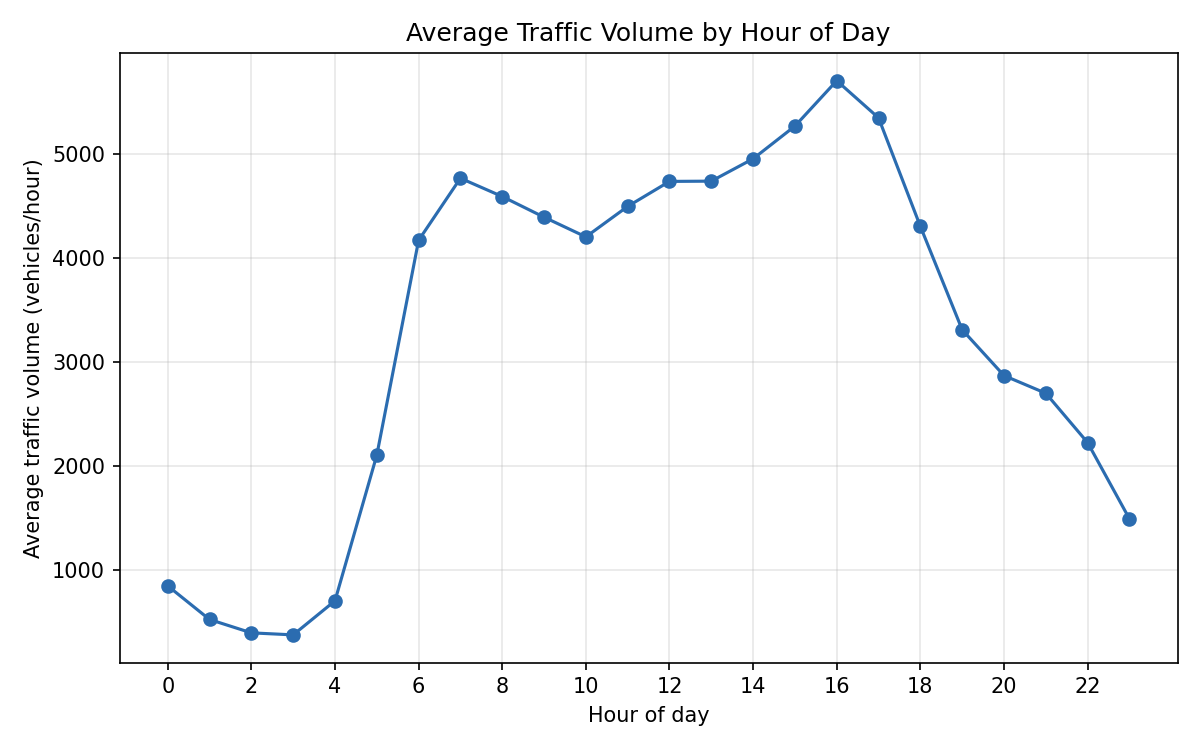

Traffic follows a clear bimodal commute pattern, peaking around 16:00. Volume is lowest overnight (roughly 00:00-04:00), consistent with a corridor dominated by commuter rather than overnight freight/leisure traffic.


In [3]:
display(Image(filename=str(visualizations.DEFAULT_FIG_DIR / "01_traffic_by_hour.png")))
print(visualizations.INTERPRETATIONS["01_traffic_by_hour.png"])

## Figure 2 — Weekday vs. weekend traffic by hour

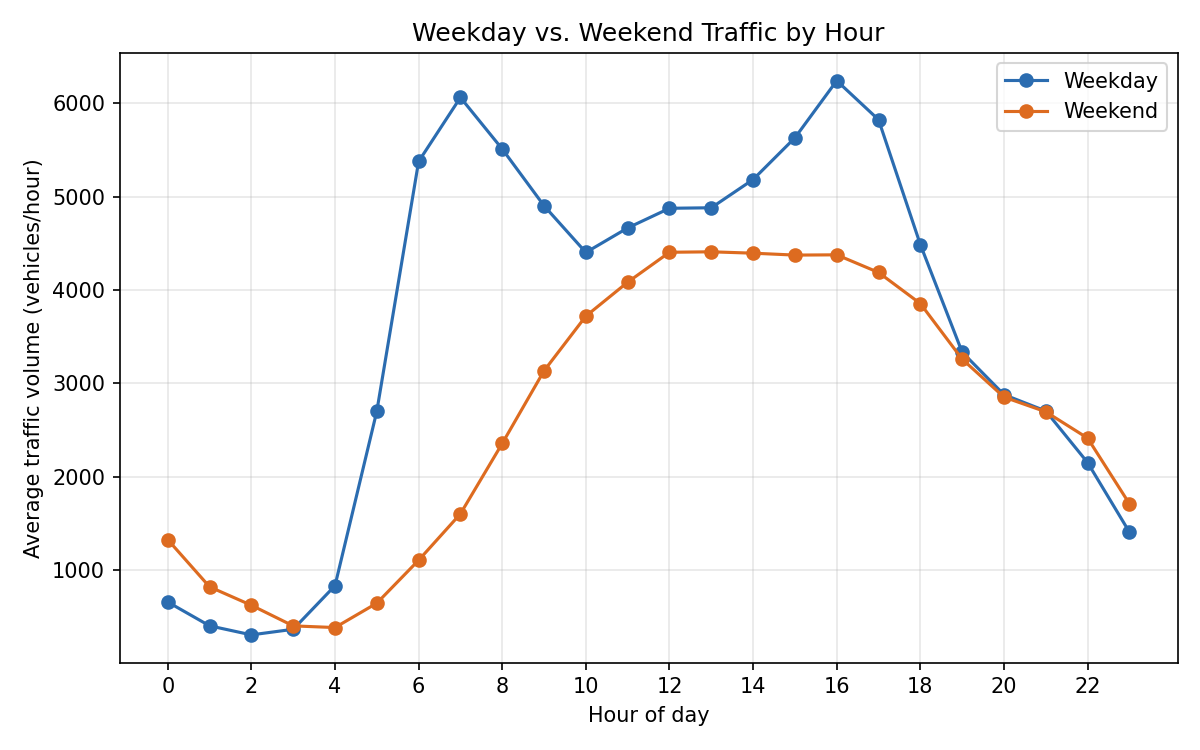

Weekday traffic shows two sharp commute peaks (morning and evening) that weekend traffic does not: weekends instead have a single, flatter midday bulge. This confirms the corridor's traffic is driven primarily by work-commute patterns rather than general leisure travel, and is one of the strongest predictive signals available for the Part 3 models.


In [4]:
display(Image(filename=str(visualizations.DEFAULT_FIG_DIR / "02_weekday_vs_weekend.png")))
print(visualizations.INTERPRETATIONS["02_weekday_vs_weekend.png"])

## Figure 3 — Distribution of traffic volume

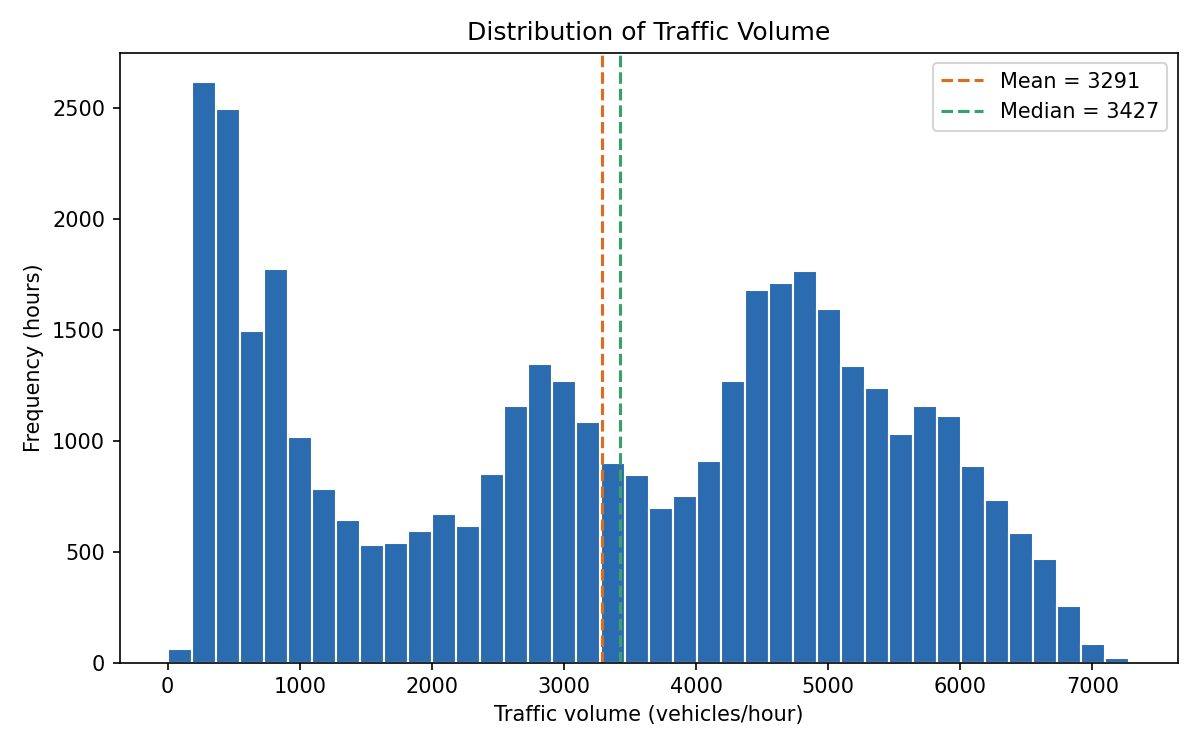

The distribution is bimodal rather than a simple bell curve: a cluster of low-traffic overnight hours, and a separate cluster of moderate-to-high daytime hours. This bimodality is exactly why the mean/median alone (Part 1, Task 2) understate how variable traffic really is — a single 'typical volume' number blends two very different regimes (night vs. day) into one figure.


In [5]:
display(Image(filename=str(visualizations.DEFAULT_FIG_DIR / "03_traffic_distribution.png")))
print(visualizations.INTERPRETATIONS["03_traffic_distribution.png"])

## Figure 4 — Average traffic volume by weather condition

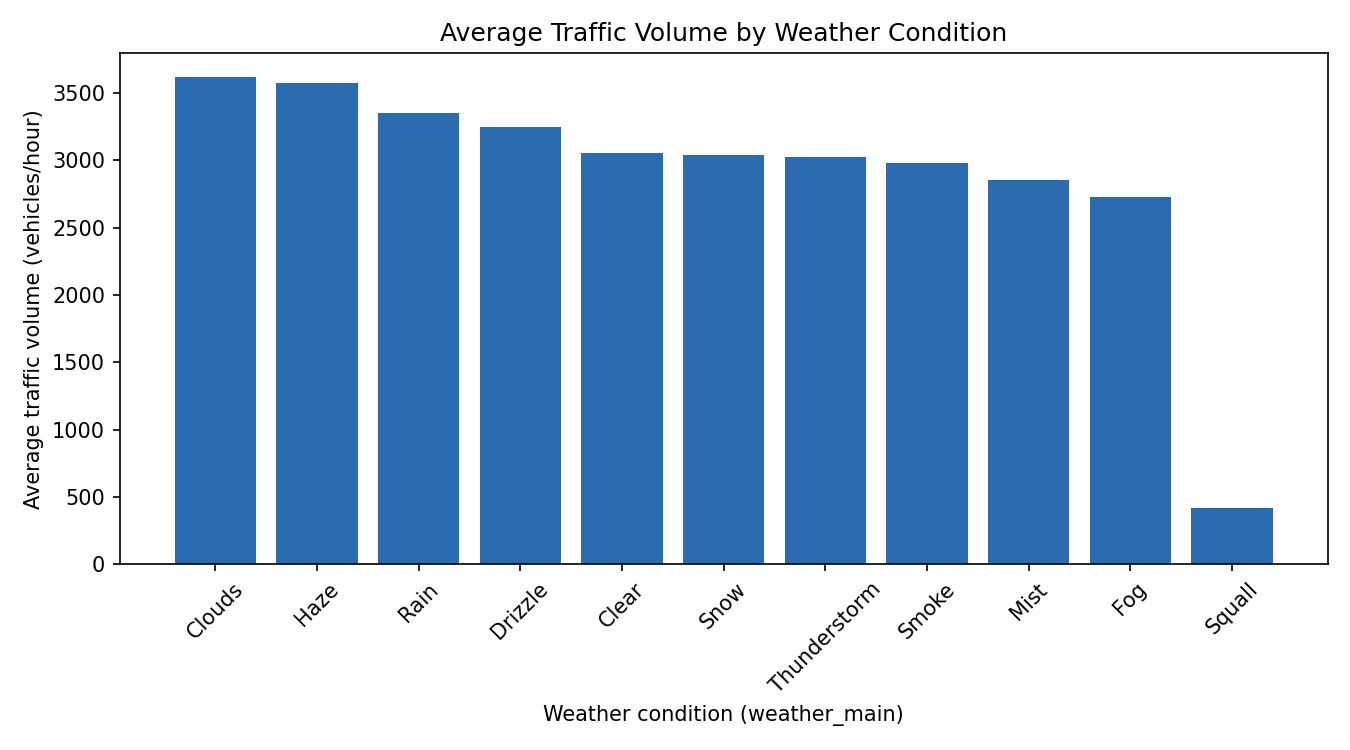

'Clouds' has the highest average traffic volume and 'Squall' the lowest, a difference of 3197 vehicles/hour. The overall spread across weather categories is modest relative to the hour-of-day effect seen in Figure 1 — consistent with the weak temperature-traffic correlation (r ≈ 0.14) and near-chance congestion/weather independence found in the Part 1 probability analysis: weather shifts traffic volume only at the margins.


In [6]:
display(Image(filename=str(visualizations.DEFAULT_FIG_DIR / "04_weather_impact.png")))
print(visualizations.INTERPRETATIONS["04_weather_impact.png"])